#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import Multi-task ElasticNet

In [3]:
import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/ElasticNet.pkl')

In [4]:
model_features = model_1.feature_names_in_
model_features

array(['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', ...,
       'ENSG00000197838', 'ENSG00000167751', 'ENSG00000182415'],
      dtype=object)

In [5]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_features.pkl', 'rb') as f:
    y_train_features_loaded = pickle.load(f)

print(y_train_features_loaded)

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)


#Import Random forest regressor

In [6]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Random Forest Regressor.pkl')

#Import ensemble

In [7]:
final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Ensemble.pkl')

#Microarray data

In [8]:
files_dict = {
'GSE26193_gene_expression.csv' : 'GSE26193_metabolomics.csv',
'GSE62452_gene_expression.csv' : 'GSE62452_metabolomics.csv',
'GSE37751_gene_expression.csv' : 'GSE37751_metabolomics.csv',
'GSE89076_gene_expression.csv' : 'GSE89076_metabolomics.csv',
'Cornell_PROSTATE_gene_expression.csv' : 'Cornell_PROSTATE_metabolomics.csv',
'Multiregions_gene_expression.csv' : 'Multiregions_metabolomics.csv',
'GSE76297_gene_expression.csv' : 'GSE76297_metabolomics.csv'
}

In [9]:
path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Microarrays/'
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Microarray_res'

#Functions

In [10]:
def filter_model_features(df):
  filtered_data = df[model_features]
  return filtered_data

In [11]:
def predict_metabolites(model, filtered_data):
  pred_metabolites = model.predict(filtered_data)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)
  return pred_metabolites

In [12]:
def predict_metabolites_ensemble(model_1, model_2, final_estimator, filtered_data):
  pred_1 = model_1.predict(filtered_data)
  pred_2 = model_2.predict(filtered_data)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)

  return pred_metabolites

In [13]:
from scipy.stats import spearmanr

metabolites_spearman_positive_all = {}
metabolites_spearman_negative_all = {}

def plot_spearman_per_metabolite(y_pred, y_true, model_name, rna_file_name):
    """Plots the Spearman's correlation coefficient per metabolite."""

    spearman_coeffs = []
    for i in range(y_true.shape[1]):
        coeff, _ = spearmanr(y_true.iloc[:, i], y_pred.iloc[:, i])
        spearman_coeffs.append(coeff)

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_true.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    dict_pos = {}
    metabolites_spearman_positive = spearman_df[spearman_df['Spearman Coefficient'] > 0]
    dict_pos[rna_file_name] =  metabolites_spearman_positive['Metabolite'].to_list()
    metabolites_spearman_positive_all.setdefault(model_name, {}).update(dict_pos)

    dict_neg = {}
    metabolites_spearman_negative = spearman_df[spearman_df['Spearman Coefficient'] < 0]
    dict_neg[rna_file_name] =  metabolites_spearman_negative['Metabolite'].to_list()
    metabolites_spearman_negative_all.setdefault(model_name, {}).update(dict_neg)

    # metabolites_spearman_positive = spearman_df[spearman_df['Spearman Coefficient'] > 0]
    # metabolites_spearman_positive_all[rna_file_name] =  metabolites_spearman_positive['Metabolite'].to_list()
    # metabolites_spearman_negative = spearman_df[spearman_df['Spearman Coefficient'] < 0]
    # metabolites_spearman_negative_all[rna_file_name] =  metabolites_spearman_negative['Metabolite'].to_list()

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name} {rna_file_name})")
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])
    plt.xticks()
    plt.xlabel("Metabolite")
    plt.savefig(f'{results_path}/Spearmans Corr per metabolite({model_name} {rna_file_name}).svg', bbox_inches = 'tight')
    plt.show()

In [14]:
def get_spearman_correlation(y_pred, y_true, model_name, rna_file_name):

  correlation, p_value = spearmanr(y_true, y_pred)

  # Use .values.ravel() or .to_numpy().flatten()
  correlation_df = pd.DataFrame({'Actual': y_true.values.ravel(), 'Predicted': y_pred.values.ravel()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name} {rna_file_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name} {rna_file_name}).svg', bbox_inches = 'tight')
  plt.show()

In [15]:
def analyse_microarray(rna_file, lcms_file):

  rna_file_name = rna_file.split('_')[0]

  print('-------------------------------------')
  print('                                     ')
  print(f'Analysing {rna_file_name} !')
  print('                                     ')
  print('-------------------------------------')

  microarray = pd.read_csv(path + rna_file, index_col=0)
  rna_filtered = filter_model_features(microarray)

  #Elastic Net predictions
  rna_pred_elastic = predict_metabolites(model_1, rna_filtered)

  #Random forest regressor predictions
  rna_pred_rf = predict_metabolites(model_2, rna_filtered)

  #Ensemble predictions
  rna_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, rna_filtered)

  #LCMS data
  lcms = pd.read_csv(path + lcms_file, index_col=0)

  #Make sure the columns are the same
  lcms = lcms[list(set(lcms.columns).intersection(set(rna_pred_elastic.columns)))]
  rna_pred_elastic = rna_pred_elastic[list(set(lcms.columns).intersection(set(rna_pred_elastic.columns)))]
  rna_pred_rf = rna_pred_rf[list(set(lcms.columns).intersection(set(rna_pred_rf.columns)))]
  rna_pred_ensemble = rna_pred_ensemble[list(set(lcms.columns).intersection(set(rna_pred_ensemble.columns)))]

  #Make sure the indexes are the same
  lcms = lcms.loc[list(set(lcms.index).intersection(set(rna_pred_elastic.index)))]
  rna_pred_elastic = rna_pred_elastic.loc[list(set(lcms.index).intersection(set(rna_pred_elastic.index)))]
  rna_pred_rf = rna_pred_rf.loc[list(set(lcms.index).intersection(set(rna_pred_rf.index)))]
  rna_pred_ensemble = rna_pred_ensemble.loc[list(set(lcms.index).intersection(set(rna_pred_ensemble.index)))]

  #Get plots

  #Spearman per metabolite
  plot_spearman_per_metabolite(y_pred = rna_pred_elastic, y_true = lcms, model_name = 'Elastic Net', rna_file_name = rna_file_name)
  plot_spearman_per_metabolite(y_pred = rna_pred_rf, y_true = lcms, model_name = 'Random Forest Regressor', rna_file_name = rna_file_name)
  plot_spearman_per_metabolite(y_pred = rna_pred_ensemble, y_true = lcms, model_name = 'Ensemble', rna_file_name = rna_file_name)

  #Spearman for the whole dataset
  get_spearman_correlation(y_pred = rna_pred_elastic, y_true = lcms, model_name = 'Elastic Net', rna_file_name = rna_file_name)
  get_spearman_correlation(y_pred = rna_pred_rf, y_true = lcms, model_name = 'Random Forest Regressor', rna_file_name = rna_file_name)
  get_spearman_correlation(y_pred = rna_pred_ensemble, y_true = lcms, model_name = 'Ensemble', rna_file_name = rna_file_name)


  print('-------------------------------------')
  print('                                     ')
  print(f'Analysis done for {rna_file_name} !')
  print('                                     ')
  print('-------------------------------------')

#Analysis

In [16]:
for item, value in files_dict.items():
  analyse_microarray(rna_file = item, lcms_file = value)

Output hidden; open in https://colab.research.google.com to view.

In [17]:
with open(results_path + 'metabolites_spearman_positive_all.pkl', 'wb') as file:
    pickle.dump(metabolites_spearman_positive_all, file)

In [18]:
with open(results_path + 'metabolites_spearman_negative_all.pkl', 'wb') as file:
    pickle.dump(metabolites_spearman_negative_all, file)

In [19]:
metabolites_spearman_positive_all

{'Elastic Net': {'GSE26193': ['ophthalmate',
   'beta-alanine',
   'sedoheptulose-7-phosphate',
   'myristoleate (14:1n5)',
   'adrenate (22:4n6)',
   'eicosenoate (20:1)',
   '10-nonadecenoate (19:1n9)',
   'fructose',
   'stearoyl sphingomyelin (d18:1/18:0)',
   'docosadienoate (22:2n6)',
   'caprate (10:0)',
   'methyl palmitate (15 or 2)',
   'gamma-glutamylglutamate',
   'alpha-tocopherol',
   'betaine',
   'dihomo-linoleate (20:2n6)',
   '4-acetamidophenylglucuronide',
   'stearate (18:0)',
   '5-oxoproline',
   'creatinine',
   '4-acetaminophen sulfate',
   '1-palmitoyl-GPC (16:0)',
   '1,5-anhydroglucitol (1,5-AG)',
   'ascorbate (Vitamin C)',
   'isovalerylcarnitine',
   'erythritol',
   '1-arachidonoyl-GPI (20:4)',
   '1-stearoyl-GPC (18:0)',
   'succinate',
   'glutamate',
   'palmitate (16:0)',
   'N6-acetyllysine',
   '10-heptadecenoate (17:1n7)',
   'p-cresol sulfate',
   'myristate (14:0)',
   '5-methylthioadenosine (MTA)',
   'tryptophan betaine ',
   'phosphocholine',


In [20]:
metabolites_spearman_negative_all

{'Elastic Net': {'GSE26193': ['isoleucine',
   'tyrosine',
   'nicotinamide adenine dinucleotide (NAD+)',
   'pentadecanoate (15:0)',
   'arachidonate (20:4n6)',
   'thymine',
   '1-oleoylglycerol (1-monoolein)',
   'sphinganine',
   'citrate',
   'pseudouridine',
   '7-alpha-hydroxy-3-oxo-4-cholestenoate (7-Hoca)',
   'butyrylcarnitine',
   "adenosine 2'-monophosphate (2'-AMP)",
   'N-acetylneuraminate',
   'aspartate',
   'arginine',
   '3-(4-hydroxyphenyl)lactate',
   "2'-deoxyguanosine",
   'histidine',
   '1-oleoyl-GPE (18:1)',
   'carnitine',
   'guanine',
   'acetylcarnitine',
   'gamma-glutamylglutamine',
   'ribose',
   'inositol 1-phosphate (I1P)',
   'phosphoethanolamine',
   'cysteine-glutathione disulfide',
   'pipecolate',
   'hippurate',
   'N-acetylalanine',
   'docosahexaenoate (DHA; 22:6n3)',
   '1-(1-enyl-palmitoyl)-GPE (P-16:0)',
   'pyroglutamine',
   '3-aminoisobutyrate',
   "adenosine 3'-monophosphate (3'-AMP)",
   'kynurenine',
   'gamma-glutamylleucine',
   'ur

In [21]:
def plot_model(model_name):
  df_pos = metabolites_spearman_positive_all[model_name]
  df_neg = metabolites_spearman_negative_all[model_name]

  positive = {}
  for item in df_pos:
    positive[item] = len(df_pos[item])
    print(item, len(df_pos[item]))
  positive = pd.DataFrame(positive, index = [0])
  positive.rename(index = {0 : 'Positive'}, inplace = True)

  negative = {}
  for item in df_neg:
    negative[item] = len(df_neg[item])
    print(item, len(df_neg[item]))
  negative = pd.DataFrame(negative, index = [0])
  negative.rename(index = {0 : 'Negative'}, inplace = True)

  pos_neg = pd.concat([positive, negative], axis = 0)
  pos_neg = pos_neg.T

  pos_neg = pos_neg.drop('GSE37751')
  pos_neg = pos_neg.sort_values(by = 'Positive', ascending = False)

  pos_neg.plot(kind = 'bar', stacked = True)
  plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
  plt.title(f"Microarrays Spearman's correlation prediction vs actual ({model_name})")
  plt.ylabel('Counts')
  plt.savefig(f'{results_path}/Microarrays_{model_name}.svg', bbox_inches = 'tight')
  plt.show()

GSE26193 99
GSE62452 58
GSE37751 0
GSE89076 24
Cornell 56
Multiregions 137
GSE76297 13
GSE26193 96
GSE62452 37
GSE37751 0
GSE89076 34
Cornell 39
Multiregions 7
GSE76297 20


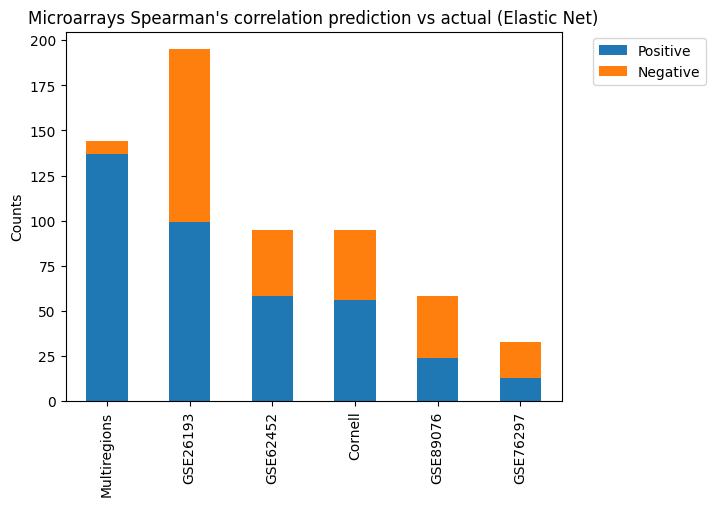

GSE26193 85
GSE62452 53
GSE37751 0
GSE89076 31
Cornell 40
Multiregions 82
GSE76297 13
GSE26193 111
GSE62452 42
GSE37751 0
GSE89076 27
Cornell 55
Multiregions 62
GSE76297 20


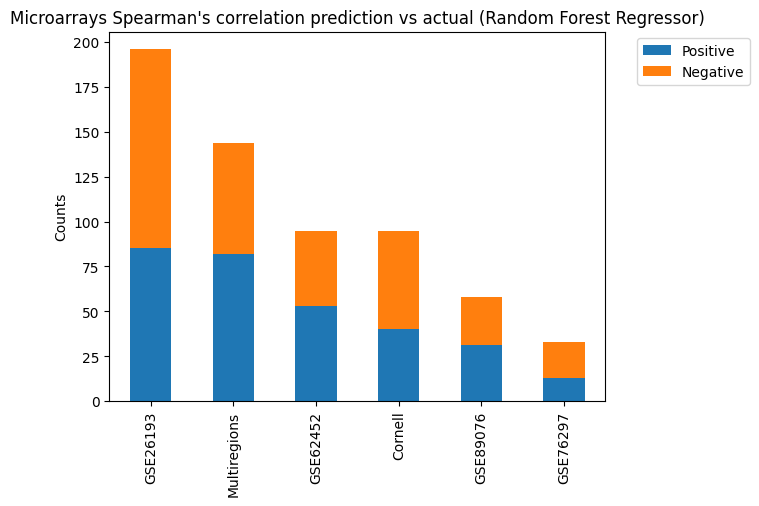

GSE26193 104
GSE62452 57
GSE37751 0
GSE89076 31
Cornell 48
Multiregions 95
GSE76297 14
GSE26193 91
GSE62452 38
GSE37751 0
GSE89076 27
Cornell 47
Multiregions 49
GSE76297 19


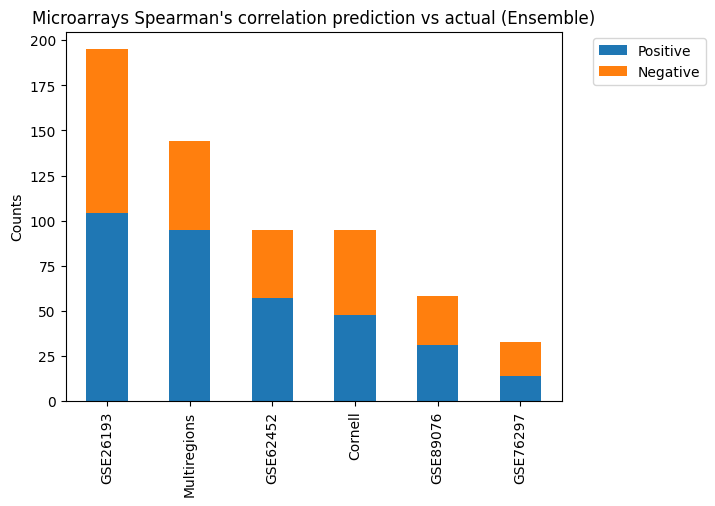

In [22]:
plot_model('Elastic Net')
plot_model('Random Forest Regressor')
plot_model('Ensemble')